In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visa_df=pd.read_csv(r'C:\Users\lokes\Documents\Data Files\Visadataset.csv')
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [3]:
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [4]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [5]:
wage_data=visa_df['prevailing_wage']
wage_data

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [6]:
Min=np.min(wage_data)
Max=np.max(wage_data)
Mean=np.mean(wage_data)
Median=np.median(wage_data)
P_25=np.percentile(wage_data,25)
P_50=np.percentile(wage_data,50)
P_75=np.percentile(wage_data,75)
count=len(wage_data)
Sd=np.std(wage_data)

In [7]:
l=[Min,Max,Mean,Median,P_25,P_75,P_50,count,Sd]
idx=['Counts','Min','25_P','Mean','Median','50_P','75_P','Max','Sd']

In [8]:
l=[]
for i in num:
    data=visa_df[i]
    count=len(data)
    Min=np.min(data)
    P_25=np.quantile(data,0.25)
    Mean=np.mean(data)
    Median=np.median(data)
    P_50=np.quantile(data,0.50)
    P_75=np.quantile(data,0.75)
    Max=np.max(data)
    SD=np.std(data)
    l.append([count,Min,P_25,Mean,Median,P_50,P_75,Max,SD])
df=pd.DataFrame(l,index=num,columns=[idx]).T
df

,no_of_employees,yr_of_estab,prevailing_wage
Counts,25480.000000,25480.000000,25480.000000
Min,-26.000000,1800.000000,2.136700
25_P,1022.000000,1976.000000,34015.480000
Mean,5667.043210,1979.409929,74455.814592
Median,2109.000000,1997.000000,70308.210000
50_P,2109.000000,1997.000000,70308.210000
75_P,3504.000000,2005.000000,107735.512500
Max,602069.000000,2016.000000,319210.270000
Sd,22877.479904,42.366098,52814.905897


In [9]:
visa_df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


**percentiles**

In [11]:
wage_data=visa_df['prevailing_wage']
np.sum(wage_data<P_25)

6370

In [12]:
wage_data=visa_df['prevailing_wage']
np.sum(wage_data<P_25)==25*25480/100

True

In [13]:
np.sum(wage_data<P_50),np.sum(wage_data<P_50)==50*25480/100

(12740, True)

In [14]:
np.sum(wage_data<P_75),np.sum(wage_data<P_75)==75*25480/100

(19110, True)

**Emperical rule**

- 68% of data coverage b/w u-1sigma to u+1sigma

In [17]:
wage_data=visa_df['prevailing_wage']
wage_data

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [18]:
Mean=np.mean(wage_data)
Mean

74455.81459209183

In [19]:
std=np.std(wage_data)
std

52814.90589711402

In [20]:
lower_bound=(Mean-1)*std
lower_bound

3932324026.2684016

In [21]:
upper_bound=(Mean+1)*std
upper_bound

3932429656.080196

In [22]:
con1=wage_data>lower_bound
con1

0        False
1        False
2        False
3        False
4        False
         ...  
25475    False
25476    False
25477    False
25478    False
25479    False
Name: prevailing_wage, Length: 25480, dtype: bool

In [23]:
con2=wage_data<upper_bound
con2

0        True
1        True
2        True
3        True
4        True
         ... 
25475    True
25476    True
25477    True
25478    True
25479    True
Name: prevailing_wage, Length: 25480, dtype: bool

In [24]:
final_con=con1 & con2
final_con

0        False
1        False
2        False
3        False
4        False
         ...  
25475    False
25476    False
25477    False
25478    False
25479    False
Name: prevailing_wage, Length: 25480, dtype: bool

In [25]:
count=np.sum(final_con)
count

0

In [26]:
np.sum(final_con)==68*(25480)/100

False

In [27]:
def emperical(num,alpha):
    wage_data=visa_df['prevailing_wage']
    Mean=np.mean(wage_data)
    std=np.std(wage_data)
    lower_bound=(Mean-alpha)*std
    upper_bound=(Mean+alpha)*std
    con1=wage_data>lower_bound
    con2=wage_data<upper_bound
    final_con=con1 & con2
    count=np.sum(final_con)
    print(np.sum(final_con)==num*(25480)/100)
emperical(68,43),
emperical(95,3),
emperical(97.5,3)

False
False
False


**histogram**

(array([6038., 5504., 5681., 4551., 2334.,  624.,  373.,  240.,  114.,
          21.]),
 array([2.13670000e+00, 3.19229500e+04, 6.38437634e+04, 9.57645767e+04,
        1.27685390e+05, 1.59606203e+05, 1.91527017e+05, 2.23447830e+05,
        2.55368643e+05, 2.87289457e+05, 3.19210270e+05]),
 <BarContainer object of 10 artists>)

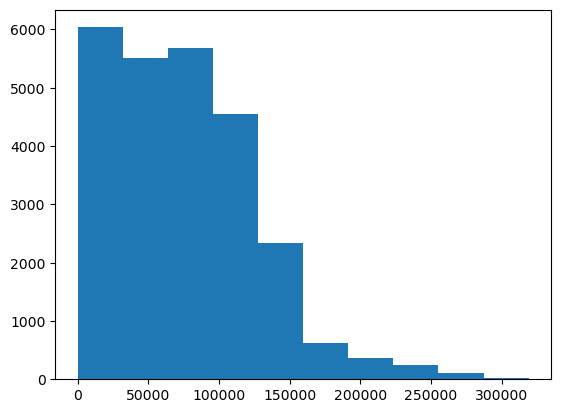

In [29]:
plt.hist(wage_data)

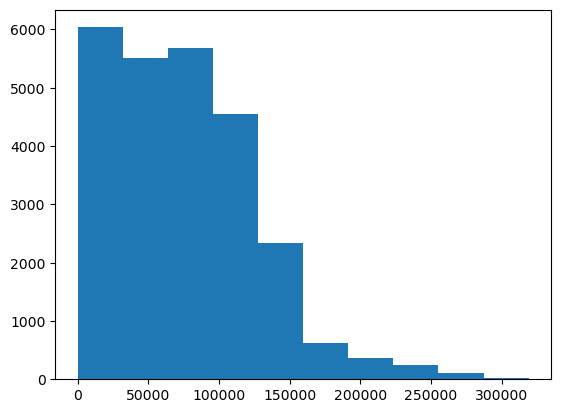

In [30]:
count,intervals,no_of_intervals=plt.hist(wage_data)

In [31]:
count

array([6038., 5504., 5681., 4551., 2334.,  624.,  373.,  240.,  114.,
         21.])

In [32]:
intervals

array([2.13670000e+00, 3.19229500e+04, 6.38437634e+04, 9.57645767e+04,
       1.27685390e+05, 1.59606203e+05, 1.91527017e+05, 2.23447830e+05,
       2.55368643e+05, 2.87289457e+05, 3.19210270e+05])

In [33]:
lower_bound=2.13670000e+00
upper_bound=6.38629937e+03
con1=wage_data>=lower_bound
con2=wage_data<=upper_bound
final_con=con1 & con2
count1=np.sum(final_con)
print(count1)
#----------------------------------------------------
lower_bound=6.38629937e+03
upper_bound=1.27704620e+04
con1=wage_data>=lower_bound
con2=wage_data<=upper_bound
final_con=con1 & con2
count2=np.sum(final_con)
print(count2)
#----------------------------------------------------
lower_bound=1.27704620e+04
upper_bound=1.91546247e+04
con1=wage_data>=lower_bound
con2=wage_data<=upper_bound
final_con=con1 & con2
count3=np.sum(final_con)
print(count3)

2813
708
725


In [34]:
l=[]
for i,j in zip(intervals,intervals[1:]):
    c=str(i)+'-'+str(j)
    l.append(c)
l

['2.1367-31922.950030000004',
 '31922.950030000004-63843.76336000001',
 '63843.76336000001-95764.57669000002',
 '95764.57669000002-127685.39002000002',
 '127685.39002000002-159606.20335000003',
 '159606.20335000003-191527.01668000003',
 '191527.01668000003-223447.83001000003',
 '223447.83001000003-255368.64334000004',
 '255368.64334000004-287289.45667000004',
 '287289.45667000004-319210.27']

In [35]:
a=l
b=count
df=pd.DataFrame(zip(a,b),columns=['no_of_intervals','Counts'])
df

,no_of_intervals,Counts
0,2.1367-31922.950030000004,6038.0
1,31922.950030000004-63843.76336000001,5504.0
2,63843.76336000001-95764.57669000002,5681.0
3,95764.57669000002-127685.39002000002,4551.0
4,127685.39002000002-159606.20335000003,2334.0
5,159606.20335000003-191527.01668000003,624.0
6,191527.01668000003-223447.83001000003,373.0
7,223447.83001000003-255368.64334000004,240.0
8,255368.64334000004-287289.45667000004,114.0
9,287289.45667000004-319210.27,21.0


**outliers analysis**

{'whiskers': [<matplotlib.lines.Line2D at 0x13442eb4e30>,
 'caps': [<matplotlib.lines.Line2D at 0x13442eb5a00>,
 'boxes': [<matplotlib.lines.Line2D at 0x13442eb51f0>],
 'medians': [<matplotlib.lines.Line2D at 0x13442eb5df0>],
 'fliers': [<matplotlib.lines.Line2D at 0x13442eb6030>],
 'means': []}

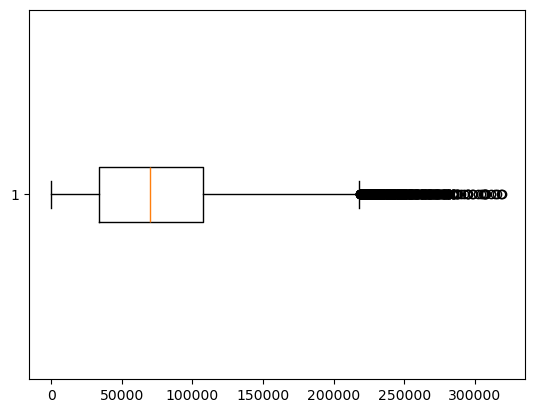

In [37]:
plt.boxplot(wage_data,vert=False)

In [38]:
Q1=np.quantile(wage_data,0.25)
Q2=np.quantile(wage_data,0.50)
Q3=np.quantile(wage_data,0.75)
IQR=Q3-Q1
lower_b=Q1-1.5*IQR
upper_b=Q3+1.5*IQR
con1=wage_data<lower_b
con2=wage_data>upper_b
outliers=con1|con2
outliers

0        False
1        False
2        False
3        False
4        False
         ...  
25475    False
25476     True
25477    False
25478    False
25479    False
Name: prevailing_wage, Length: 25480, dtype: bool

In [39]:
outliers_df=wage_data[outliers]

In [50]:
visa_df[outliers]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
14,EZYV15,Asia,Master's,Y,Y,15756,2006,South,220081.73,Year,Y,Certified
34,EZYV35,Asia,Master's,N,N,1809,2010,South,225569.73,Year,N,Certified
130,EZYV131,South America,High School,N,N,2554,2005,Midwest,247393.01,Year,Y,Certified
216,EZYV217,Asia,Master's,Y,N,1515,2001,Midwest,269321.68,Year,N,Certified
221,EZYV222,North America,Doctorate,Y,Y,2518,2010,South,219529.62,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25191,EZYV25192,Asia,Master's,N,N,4983,2005,Midwest,280482.51,Year,Y,Denied
25195,EZYV25196,North America,Master's,Y,N,47,2001,South,234308.77,Year,N,Certified
25468,EZYV25469,Asia,Bachelor's,N,N,373,2005,Midwest,272715.74,Year,N,Certified
25469,EZYV25470,North America,Master's,Y,N,2261,1997,Northeast,273772.47,Year,N,Certified


**Imputation of outliers**

In [54]:
# wage_median=visa_df['prevailing_wage'].median()
# l1=visa_df['prevailing_wage']
# l2=outliers['prevailing_wage']
# l3=[]
# for i in l1:
#     if i in l2:
#         l3.append(wage_median)
#     else:
#         l3.append(i)
wage_median = visa_df['prevailing_wage'].median()

l1 = visa_df['prevailing_wage']

# If outliers_df is Series → convert to set
l2 = set(outliers_df)

l3 = []
for i in l1:
    if i in l2:
        l3.append(wage_median)
    else:
        l3.append(i)

{'whiskers': [<matplotlib.lines.Line2D at 0x134527751c0>,
 'caps': [<matplotlib.lines.Line2D at 0x134527756d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x13452774f20>],
 'medians': [<matplotlib.lines.Line2D at 0x13452775af0>],
 'fliers': [<matplotlib.lines.Line2D at 0x13452775d60>],
 'means': []}

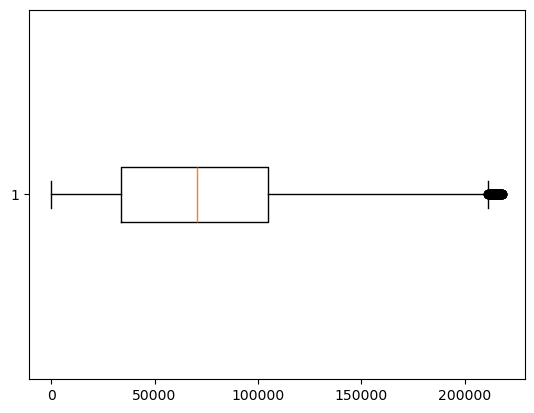

In [58]:
plt.boxplot(l3,vert=False)

**clip method or winsorization**

- we will fill less than lowerbound values with lowerbound
- we will fill greater than upperbound with upper bound


In [62]:
print('lower_b',lower_b)
print('upper_b',upper_b)
new_wage_data=wage_data.clip(lower_b,upper_b)

lower_b -76564.56875000002
upper_b 218315.56125000003


**ScatterPlots**

- A plot between **numerical vs numerical**

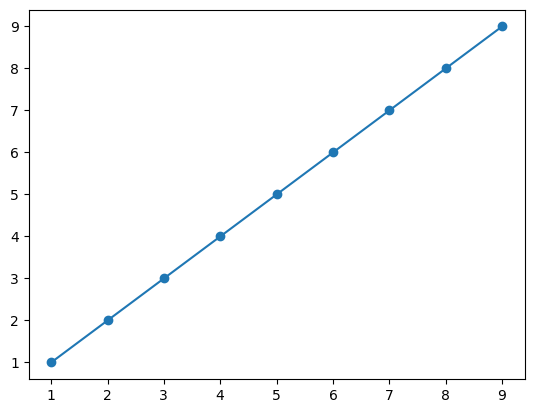

In [66]:
l1=range(1,10)
l2=range(1,10)
plt.scatter(l1,l2)
plt.plot(l1,l2)

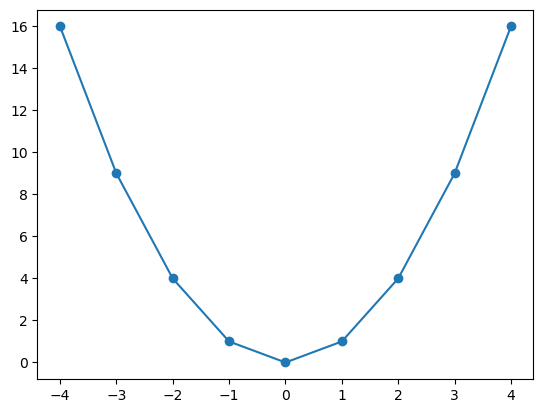

In [68]:
l1=[-4,-3,-2,-1,0,1,2,3,4]
l2=[16,9,4,1,0,1,4,9,16]
plt.scatter(l1,l2)
plt.plot(l1,l2)

In [70]:
visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [72]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [78]:
con1=visa_df['continent']=='Asia'
con2=visa_df['case_status']=='Certified'
con=con1&con2
np.sum(con)
visa_df[con]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
5,EZYV06,Asia,Master's,Y,N,2339,2012,South,78252.14,Year,Y,Certified
6,EZYV07,Asia,Bachelor's,N,N,4985,1994,South,53635.39,Year,Y,Certified
8,EZYV09,Asia,Bachelor's,N,N,4810,2012,Midwest,74362.19,Year,Y,Certified
10,EZYV11,Asia,Master's,N,N,2465,2004,Midwest,83588.56,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified


In [80]:
con1=visa_df['continent']=='Asia'
con2=visa_df['case_status']=='Denied'
con=con1&con2
np.sum(con)
visa_df[con]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
11,EZYV12,Asia,High School,Y,N,4069,2005,Northeast,70813.0900,Year,Y,Denied
15,EZYV16,Asia,High School,Y,N,4897,1987,West,74108.0200,Year,Y,Denied
...,...,...,...,...,...,...,...,...,...,...,...,...
25450,EZYV25451,Asia,Bachelor's,N,N,3312,2009,Northeast,682.1048,Hour,Y,Denied
25452,EZYV25453,Asia,High School,N,N,70,1995,Northeast,84833.8900,Year,Y,Denied
25454,EZYV25455,Asia,Bachelor's,N,N,1316,2007,South,62844.9700,Year,Y,Denied
25459,EZYV25460,Asia,High School,Y,N,4727,1990,Midwest,53952.8400,Year,Y,Denied


In [82]:
con1=visa_df['continent']=='Europe'
con2=visa_df['case_status']=='Certified'
con=con1&con2
np.sum(con)
visa_df[con]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
9,EZYV10,Europe,Doctorate,Y,N,2251,1995,South,67514.76,Year,Y,Certified
16,EZYV17,Europe,Master's,Y,N,76638,1991,Midwest,3706.79,Year,Y,Certified
24,EZYV25,Europe,Doctorate,Y,N,241,1981,Midwest,71286.04,Year,Y,Certified
37,EZYV38,Europe,Master's,Y,Y,44,1965,South,110817.26,Year,Y,Certified
42,EZYV43,Europe,Doctorate,Y,N,19770,2005,West,43630.58,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25420,EZYV25421,Europe,Master's,Y,Y,799,2003,Northeast,58608.40,Year,Y,Certified
25426,EZYV25427,Europe,Doctorate,N,N,171,1977,South,7058.51,Year,Y,Certified
25435,EZYV25436,Europe,Bachelor's,N,N,1606,1998,South,126329.96,Year,Y,Certified
25448,EZYV25449,Europe,Doctorate,Y,N,4119,1971,West,86894.10,Year,Y,Certified


In [84]:
con1=visa_df['continent']=='Europe'
con2=visa_df['case_status']=='Denied'
con=con1&con2
np.sum(con)
visa_df[con]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
36,EZYV37,Europe,High School,Y,N,2520,1981,West,2490.12,Year,Y,Denied
72,EZYV73,Europe,Bachelor's,Y,N,3339,1935,Northeast,121316.50,Year,Y,Denied
187,EZYV188,Europe,High School,Y,N,600,2009,Northeast,138032.00,Year,Y,Denied
223,EZYV224,Europe,Bachelor's,N,N,787,1913,Northeast,158569.72,Year,N,Denied
240,EZYV241,Europe,High School,Y,N,2216,2000,Northeast,26325.98,Year,Y,Denied
...,...,...,...,...,...,...,...,...,...,...,...,...
25317,EZYV25318,Europe,Bachelor's,Y,N,1152,2013,South,49941.93,Year,Y,Denied
25331,EZYV25332,Europe,Master's,N,N,1813,2010,West,33556.69,Year,Y,Denied
25414,EZYV25415,Europe,Master's,N,N,724,1998,West,7546.99,Year,Y,Denied
25462,EZYV25463,Europe,Bachelor's,N,Y,1715,2004,West,166032.62,Year,Y,Denied


In [92]:
Certified_con,Denied_con=[],[]
Continent_labels=visa_df['continent'].unique()
for i in Continent_labels:
    
    con1=visa_df['continent']==i
    con2=visa_df['case_status']=='Certified'
    con3=visa_df['case_status']=='Denied'
    certi_con=con1&con2
    deni_con=con1&con2
    np.sum(con)
    visa_df[con]
    Certified_con.append(np.sum(certi_con))
    Denied_con.append(np.sum(deni_con))

In [94]:
df=pd.DataFrame()
df['Continents']=Continent_labels
df['Certified_con']=Certified_con
df['Denied_con']=Denied_con
df

,Continents,Certified_con,Denied_con
0,Asia,11012,11012
1,Africa,397,397
2,North America,2037,2037
3,Europe,2957,2957
4,South America,493,493
5,Oceania,122,122


**Group_by**

In [97]:
visa_df.groupby('continent')

In [99]:
list(visa_df.groupby('continent'))

[('Africa',
           case_id continent education_of_employee has_job_experience  \
  4         EZYV05    Africa              Master's                  Y   
  18        EZYV19    Africa              Master's                  Y   
  74        EZYV75    Africa              Master's                  Y   
  194      EZYV195    Africa              Master's                  Y   
  242      EZYV243    Africa            Bachelor's                  N   
  ...          ...       ...                   ...                ...   
  25385  EZYV25386    Africa             Doctorate                  Y   
  25408  EZYV25409    Africa              Master's                  Y   
  25443  EZYV25444    Africa            Bachelor's                  N   
  25446  EZYV25447    Africa              Master's                  N   
  25474  EZYV25475    Africa             Doctorate                  N   
  
        requires_job_training  no_of_employees  yr_of_estab  \
  4                         N             1082

In [101]:
list(visa_df.groupby('continent'))[0]

('Africa',
          case_id continent education_of_employee has_job_experience  \
 4         EZYV05    Africa              Master's                  Y   
 18        EZYV19    Africa              Master's                  Y   
 74        EZYV75    Africa              Master's                  Y   
 194      EZYV195    Africa              Master's                  Y   
 242      EZYV243    Africa            Bachelor's                  N   
 ...          ...       ...                   ...                ...   
 25385  EZYV25386    Africa             Doctorate                  Y   
 25408  EZYV25409    Africa              Master's                  Y   
 25443  EZYV25444    Africa            Bachelor's                  N   
 25446  EZYV25447    Africa              Master's                  N   
 25474  EZYV25475    Africa             Doctorate                  N   
 
       requires_job_training  no_of_employees  yr_of_estab  \
 4                         N             1082         2005   

In [103]:
list(visa_df.groupby('continent'))[0][1]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified
18,EZYV19,Africa,Master's,Y,N,4743,2004,Midwest,150441.13,Year,Y,Certified
74,EZYV75,Africa,Master's,Y,N,3705,2001,South,47170.76,Year,Y,Certified
194,EZYV195,Africa,Master's,Y,N,2180,1992,Midwest,113637.40,Year,Y,Certified
242,EZYV243,Africa,Bachelor's,N,Y,2509,2003,West,51886.04,Year,Y,Denied
...,...,...,...,...,...,...,...,...,...,...,...,...
25385,EZYV25386,Africa,Doctorate,Y,N,2513,1975,West,76348.20,Year,Y,Certified
25408,EZYV25409,Africa,Master's,Y,Y,1671,1992,Midwest,55756.35,Year,Y,Certified
25443,EZYV25444,Africa,Bachelor's,N,N,72892,2007,Northeast,215.10,Hour,Y,Certified
25446,EZYV25447,Africa,Master's,N,Y,2024,1971,South,42353.45,Year,Y,Certified


**pd.crosstab**

In [106]:
idx=visa_df['continent']
cols=visa_df['case_status']
pd.crosstab(idx,cols)

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [115]:
idx=visa_df['continent']
cols1=visa_df['case_status']
cols2=visa_df['education_of_employee']
cols=[cols1,cols2]
pd.crosstab(idx,cols)

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

**numerical vs numerical**

In [118]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [130]:
visa_df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


C:\anakonda\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\anakonda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


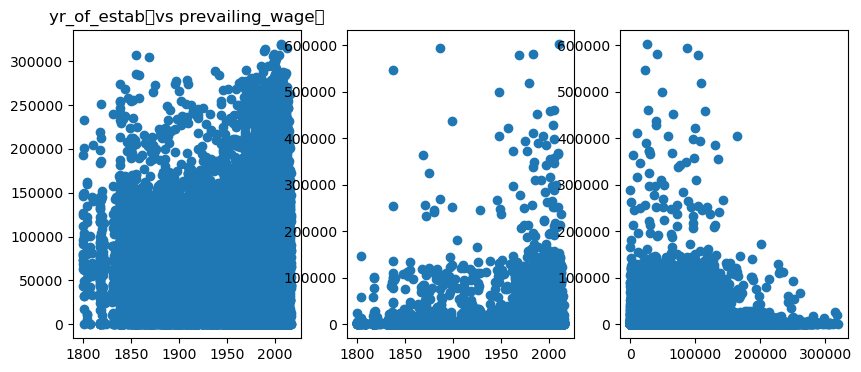

In [132]:
con1=visa_df['yr_of_estab']
con2=visa_df['prevailing_wage']
con3=visa_df['no_of_employees']
plt.figure(figsize=(10,4))
plt.subplot(1,3,1).scatter(con1,con2)
plt.title('yr_of_estab	vs prevailing_wage	')
plt.subplot(1,3,2).scatter(con1,con3)
plt.subplot(1,3,3).scatter(con2,con3)

In [138]:
winequality_df=pd.read_csv(r'C:\Users\lokes\Documents\Data Files\winequality_red.csv')
winequality_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [140]:
num=winequality_df.select_dtypes(exclude='object').columns

In [142]:
num

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [144]:
winequality_df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


C:\anakonda\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\anakonda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


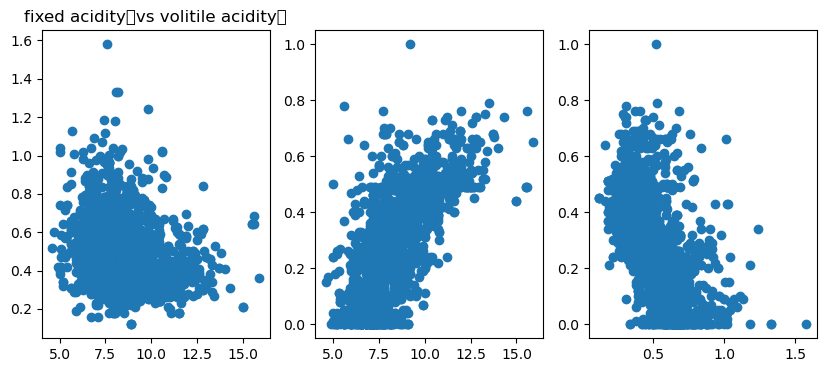

In [146]:

con1=winequality_df['fixed acidity']
con2=winequality_df['volatile acidity']
con3=winequality_df['citric acid']
plt.figure(figsize=(10,4))
plt.subplot(1,3,1).scatter(con1,con2)
plt.title('fixed acidity	vs volitile acidity	')
plt.subplot(1,3,2).scatter(con1,con3)
plt.subplot(1,3,3).scatter(con2,con3)

**heatmap**

In [149]:
corr=winequality_df.corr()
corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


<Axes: >

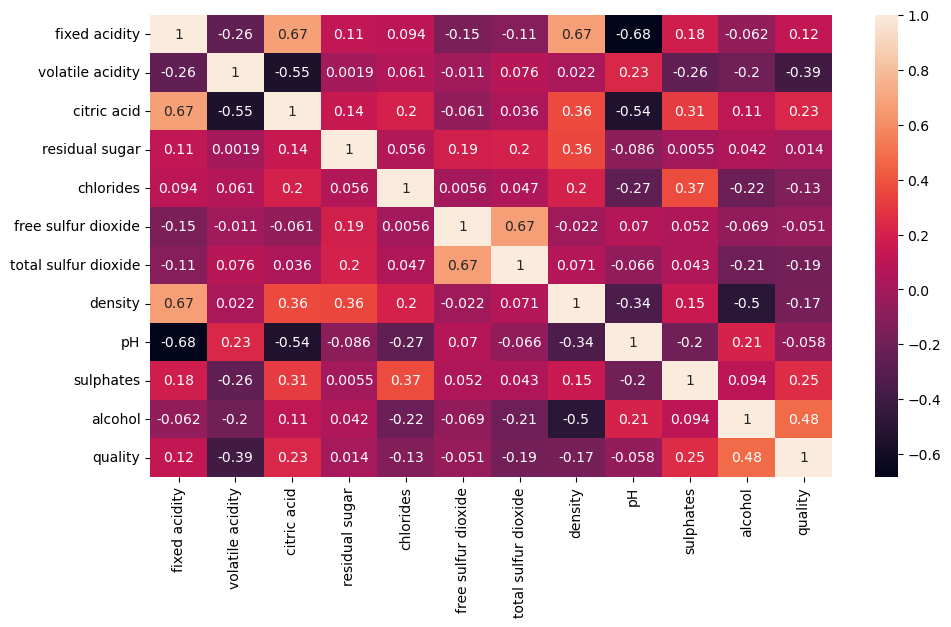

In [163]:
plt.figure(figsize=(11,6))
sns.heatmap(corr,annot=True)

In [ ]:
quality_corr = corr['quality'].drop('quality')
high = quality_corr[quality_corr.abs() >= 0.3]
low = quality_corr[(quality_corr.abs() >= 0.1) & (quality_corr.abs() < 0.3)]
no_relation = quality_corr[quality_corr.abs() < 0.1]

fixed_acidity_corr=corr['fixed acidity'].drop('fixed acidity')
high = fixed_acidity_corr[fixed_acidity_corr.abs() >= 0.3]
low = fixed_acidity_corr[(fixed_acidity_corr.abs() >= 0.1) & (fixed_acidity_corr.abs() < 0.3)]
no_relation = fixed_acidity_corr[fixed_acidity_corr.abs() < 0.1]



con1=winequality_df['fixed acidity']
con2=winequality_df['volatile acidity']
con3=winequality_df['citric acid']
plt.figure(figsize=(10,4))
plt.subplot(1,3,1).scatter(con1,con2)
plt.title('fixed acidity	vs volitile acidity	')
plt.subplot(1,3,2).scatter(con1,con3)
plt.subplot(1,3,3).scatter(con2,con3)